In [1]:
import pandas as pd
import numpy as np

In [83]:
df = pd.read_csv("coustmer_analytics.csv")

In [84]:




df.head()

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100


# Mini Project – Exploratory Data Analysis (Customer Analytics Dataset)

## Dataset Overview

This dataset contains information about customers including demographic details, purchasing behavior, and online activity.

Each row represents a single customer.

The dataset includes attributes such as age, gender, city, education, income, spending score, purchase frequency, and last purchase amount.

The goal of this project is to analyze customer behavior patterns and relationships among different features.

In [85]:
import os
os.listdir()



['coustmer_analytics.csv', 'dataset.csv', 'MiniProject1_EDA.ipynb']

In [86]:
df.info()
df.describe()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB


(255, 14)

# Phase 2 – Data Cleaning Decisions

Missing values were identified in columns such as AnnualIncome and Education.  
Numerical missing values were filled using the mean, and categorical values were filled using the mode to preserve dataset size.

Duplicate rows were found in the dataset and removed using drop_duplicates() to ensure data accuracy.

In [87]:
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
City                     0
Education               12
MaritalStatus            0
AnnualIncome            12
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64

In [90]:
df['AnnualIncome'].fillna(df['AnnualIncome'].mean(), inplace=True)

C:\Users\Shashirekha\AppData\Local\Temp\ipykernel_9632\1750084453.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AnnualIncome'].fillna(df['AnnualIncome'].mean(), inplace=True)


In [91]:
df['Education'].fillna(df['Education'].mode()[0], inplace=True)

C:\Users\Shashirekha\AppData\Local\Temp\ipykernel_9632\593309154.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Education'].fillna(df['Education'].mode()[0], inplace=True)


In [92]:
(df.isnull().sum() / len(df)) * 100

CustomerID              0.0
Age                     0.0
Gender                  0.0
City                    0.0
Education               0.0
MaritalStatus           0.0
AnnualIncome            0.0
SpendingScore           0.0
YearsEmployed           0.0
PurchaseFrequency       0.0
OnlineVisitsPerMonth    0.0
ReturnedItems           0.0
PreferredDevice         0.0
LastPurchaseAmount      0.0
dtype: float64

In [89]:
df = df.dropna()

In [93]:
df.duplicated().sum()

5

In [94]:
df = df.drop_duplicates()

# Phase 2 – Data Cleaning Decisions

Missing values were identified in columns such as AnnualIncome and Education.  
Numerical missing values were filled using the mean, and categorical values were filled using the mode to preserve dataset size.

Duplicate rows were found in the dataset and removed using drop_duplicates() to ensure data accuracy.

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

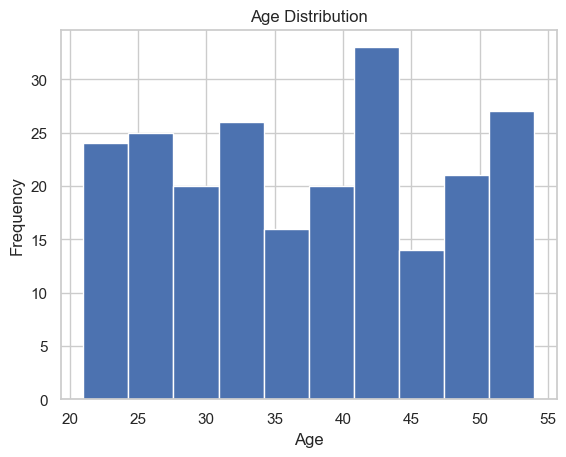

In [103]:
plt.hist(df['Age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

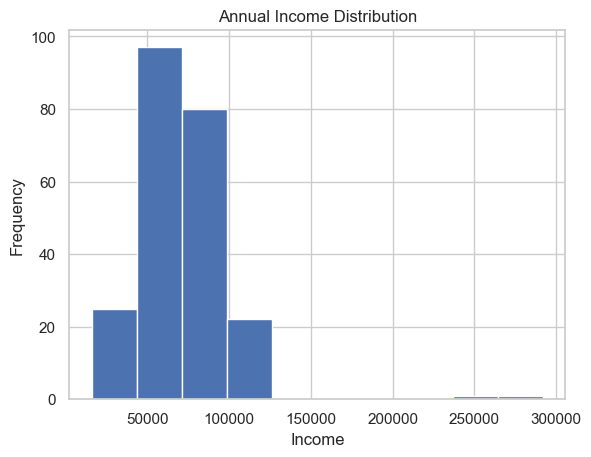

In [104]:
plt.hist(df['AnnualIncome'])
plt.title("Annual Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

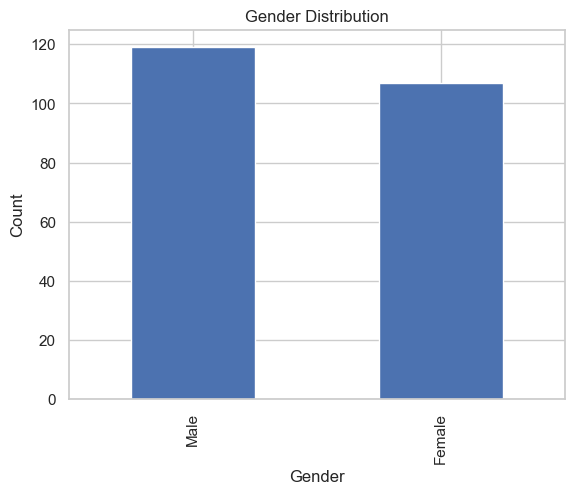

In [105]:
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

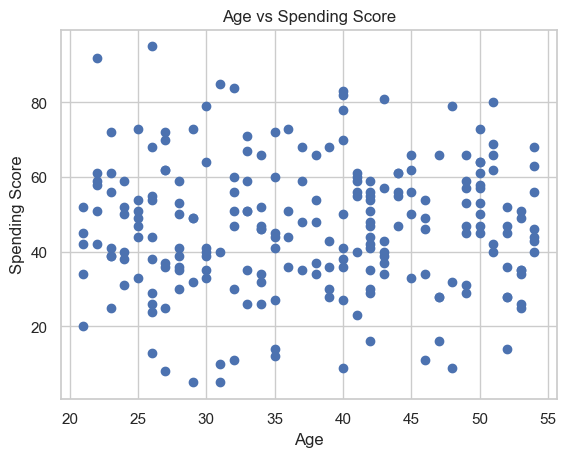

In [106]:
plt.scatter(df['Age'], df['SpendingScore'])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending Score")
plt.show()

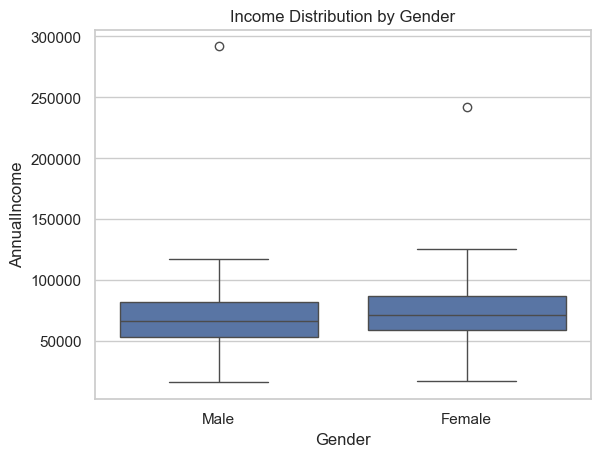

In [107]:
sns.boxplot(x='Gender', y='AnnualIncome', data=df)
plt.title("Income Distribution by Gender")
plt.show()

The chart shows that most customers are between 25 and 50 years old.

The scatter plot indicates no strong relationship between age and spending score.

# Phase 4 – The Big Picture (Multivariate Analysis & Storytelling)

In [109]:
corr = df.corr(numeric_only=True)
corr

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
CustomerID,1.000000,-0.014597,0.082546,0.060615,0.002904,-0.069402,-0.049251,-0.000549,-0.012880
Age,-0.014597,1.000000,-0.046136,0.013756,0.975653,0.092497,-0.018838,-0.068220,0.081990
AnnualIncome,0.082546,-0.046136,1.000000,-0.380505,-0.061575,-0.017212,0.026108,-0.035158,-0.067811
SpendingScore,0.060615,0.013756,-0.380505,1.000000,0.008340,0.029553,-0.065594,0.053308,0.043439
YearsEmployed,0.002904,0.975653,-0.061575,0.008340,1.000000,0.065481,-0.035180,-0.063214,0.099799
PurchaseFrequency,-0.069402,0.092497,-0.017212,0.029553,0.065481,1.000000,-0.065056,0.077764,-0.054932
OnlineVisitsPerMonth,-0.049251,-0.018838,0.026108,-0.065594,-0.035180,-0.065056,1.000000,-0.025769,-0.001448
ReturnedItems,-0.000549,-0.068220,-0.035158,0.053308,-0.063214,0.077764,-0.025769,1.000000,0.045238
LastPurchaseAmount,-0.012880,0.081990,-0.067811,0.043439,0.099799,-0.054932,-0.001448,0.045238,1.000000


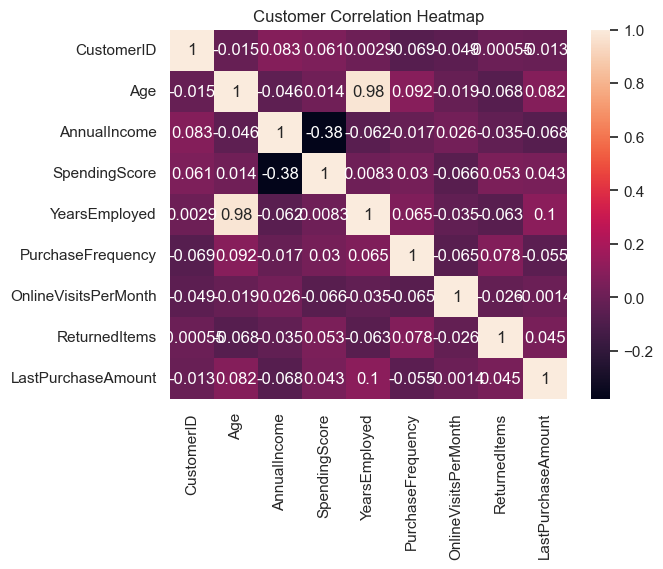

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Customer Correlation Heatmap")
plt.show()

# Executive Summary

1. Customer age mostly ranges between 25 and 50 years.
2. Annual income and spending score show moderate correlation, indicating higher income customers tend to spend more.
3. Purchase frequency is influenced by online visits and spending score.

Overall, the dataset provides insights into customer behavior and can be used for marketing and predictive analytics.